In [3]:
import pandas as pd

df = pd.read_csv("healthcare_noshows_appt.csv")



In [5]:
df['NoShow'] = df['Showed_up'].apply(lambda x: 0 if x else 1)
df.drop('Showed_up', axis=1, inplace=True)

In [6]:
df.rename(columns={
    'Hipertension': 'Hypertension',
    'Handcap': 'Handicap',
    'Date.diff': 'WaitingDays'
}, inplace=True)

In [7]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

In [8]:
# Day of week
df['AppointmentWeekday'] = df['AppointmentDay'].dt.day_name()

# Scheduled weekday
df['ScheduledWeekday'] = df['ScheduledDay'].dt.day_name()

In [13]:
columns_to_drop = ['PatientId', 'AppointmentID', 'Neighbourhood']
existing_columns = [col for col in columns_to_drop if col in df.columns]

if existing_columns:
    df.drop(existing_columns, axis=1, inplace=True)
    print(f"Dropped columns: {existing_columns}")
else:
    print(f"None of the specified columns ({columns_to_drop}) were found in the DataFrame to drop.")

None of the specified columns (['PatientId', 'AppointmentID', 'Neighbourhood']) were found in the DataFrame to drop.


In [14]:
df = df[df['Age'] >= 0]

In [15]:
df = df[df['WaitingDays'] >= 0]

<Axes: xlabel='NoShow', ylabel='count'>

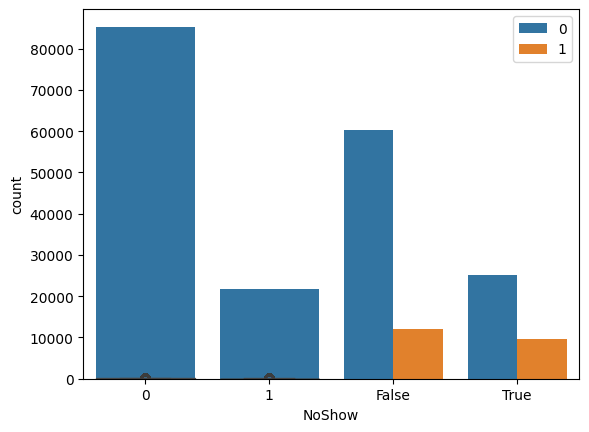

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# No-show distribution
sns.countplot(x='NoShow', data=df)

# Age vs No-show
sns.boxplot(x='NoShow', y='Age', data=df)

# SMS impact
sns.countplot(x='SMS_received', hue='NoShow', data=df)

# Waiting days impact
sns.boxplot(x='NoShow', y='WaitingDays', data=df)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

# Drop the original datetime columns as they are not suitable for direct model input
df.drop(['ScheduledDay', 'AppointmentDay'], axis=1, inplace=True)

X = df.drop('NoShow', axis=1)
y = df['NoShow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     17105
           1       0.41      0.00      0.01      4292

    accuracy                           0.80     21397
   macro avg       0.60      0.50      0.45     21397
weighted avg       0.72      0.80      0.71     21397



In [19]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
WaitingDays,0.825876
Age,0.128978
SMS_received,0.026744
Gender_M,0.006573
Alcoholism,0.003257
Scholarship,0.003255
ScheduledWeekday_Monday,0.003242
AppointmentWeekday_Wednesday,0.000967
Diabetes,0.000834
AppointmentWeekday_Thursday,0.000198


In [25]:
import pandas as pd

df = pd.read_csv("healthcare_noshows_appt.csv")

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,True,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0


In [24]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106987 entries, 0 to 106986
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       106987 non-null  float64
 1   AppointmentID   106987 non-null  int64  
 2   Gender          106987 non-null  object 
 3   ScheduledDay    106987 non-null  object 
 4   AppointmentDay  106987 non-null  object 
 5   Age             106987 non-null  int64  
 6   Neighbourhood   106987 non-null  object 
 7   Scholarship     106987 non-null  bool   
 8   Hipertension    106987 non-null  bool   
 9   Diabetes        106987 non-null  bool   
 10  Alcoholism      106987 non-null  bool   
 11  Handcap         106987 non-null  bool   
 12  SMS_received    106987 non-null  bool   
 13  Showed_up       106987 non-null  bool   
 14  Date.diff       106987 non-null  int64  
dtypes: bool(7), float64(1), int64(3), object(4)
memory usage: 7.2+ MB


In [26]:
df.to_csv("cleaned_healthcare_noshows_appt.csv", index=False)